In [1]:
# Heart Disease Prediction
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap
import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv('dataset.csv')
# Clean column names to match the prompt
df.columns = df.columns.str.replace(' ', '').str.lower()
df.rename(columns={'target': 'class', 'chestpaintype': 'chestpaintype', 'restingbps': 'restingbps', 'fastingbloodsugar': 'fastingbloodsugar', 'restingecg': 'restingecg', 'maxheartrate': 'maxheartrate', 'exerciseangina': 'exerciseangina', 'stslope': 'stslope'}, inplace=True)
df.head()

,age,sex,chestpaintype,restingbps,cholesterol,fastingbloodsugar,restingecg,maxheartrate,exerciseangina,oldpeak,stslope,class
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
# Basic info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1190 non-null   int64  
 1   sex                1190 non-null   int64  
 2   chestpaintype      1190 non-null   int64  
 3   restingbps         1190 non-null   int64  
 4   cholesterol        1190 non-null   int64  
 5   fastingbloodsugar  1190 non-null   int64  
 6   restingecg         1190 non-null   int64  
 7   maxheartrate       1190 non-null   int64  
 8   exerciseangina     1190 non-null   int64  
 9   oldpeak            1190 non-null   float64
 10  stslope            1190 non-null   int64  
 11  class              1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


age                  0
sex                  0
chestpaintype        0
restingbps           0
cholesterol          0
fastingbloodsugar    0
restingecg           0
maxheartrate         0
exerciseangina       0
oldpeak              0
stslope              0
class                0
dtype: int64

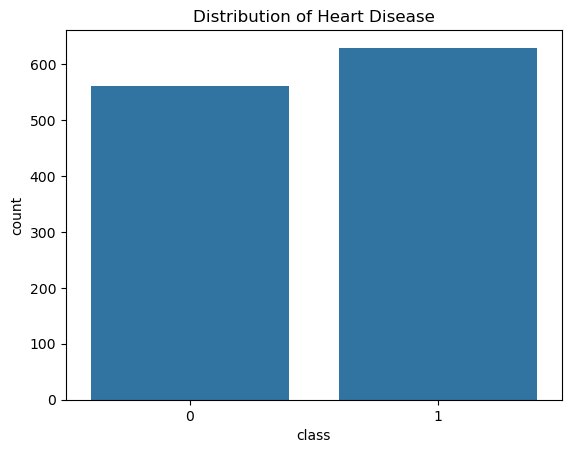

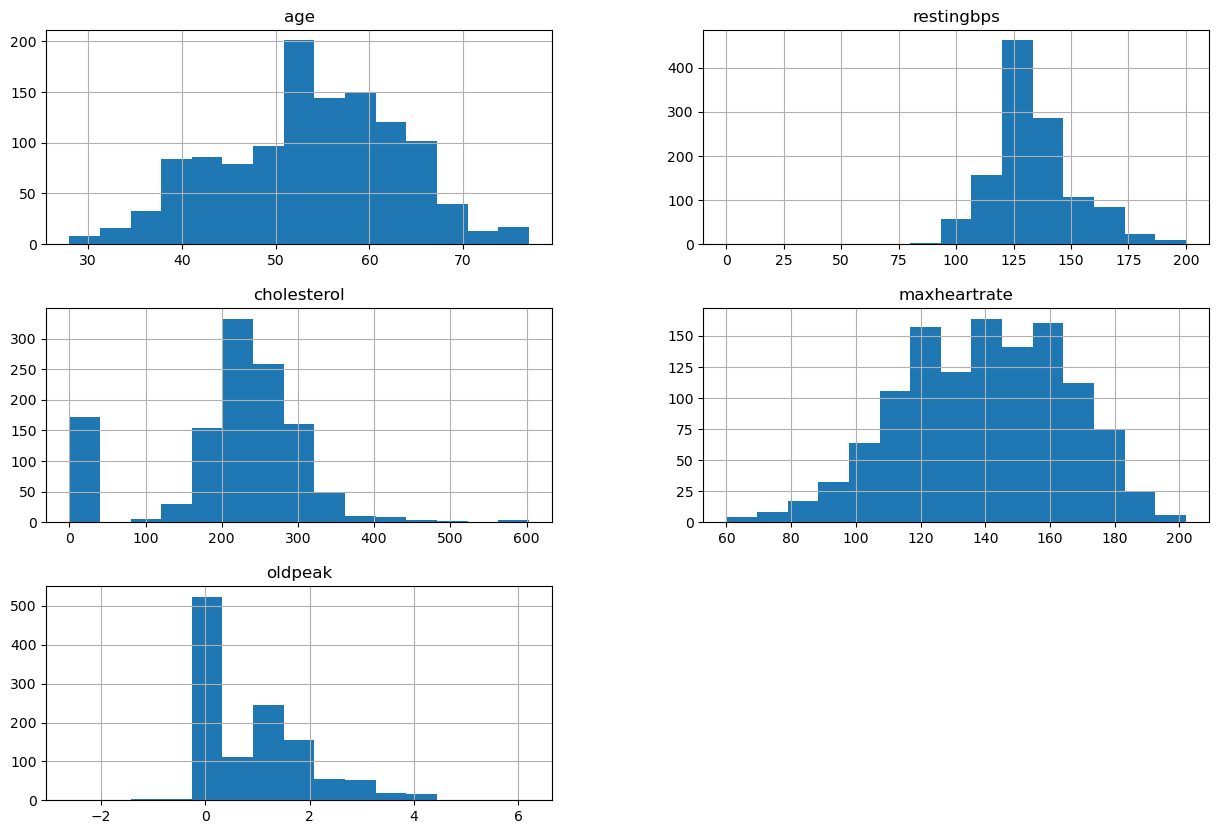

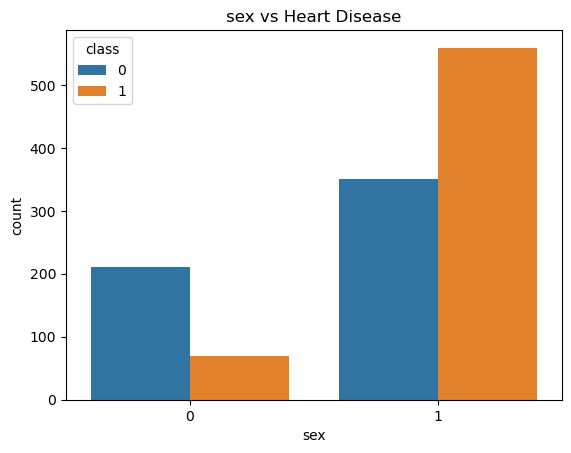

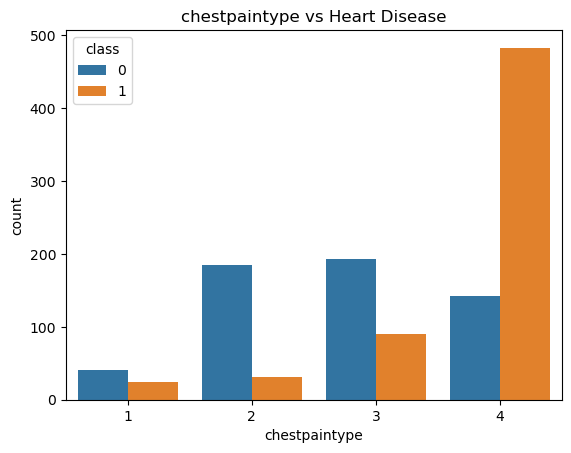

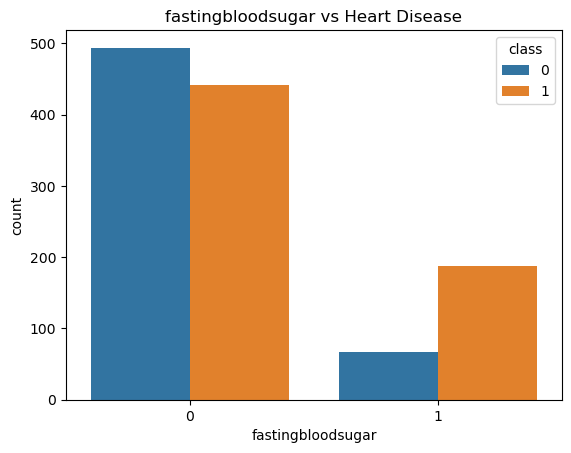

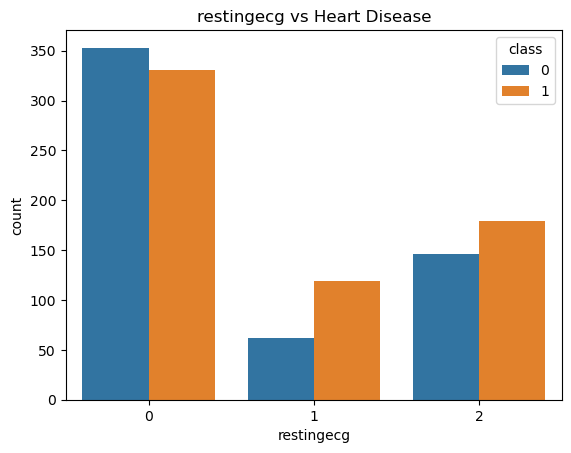

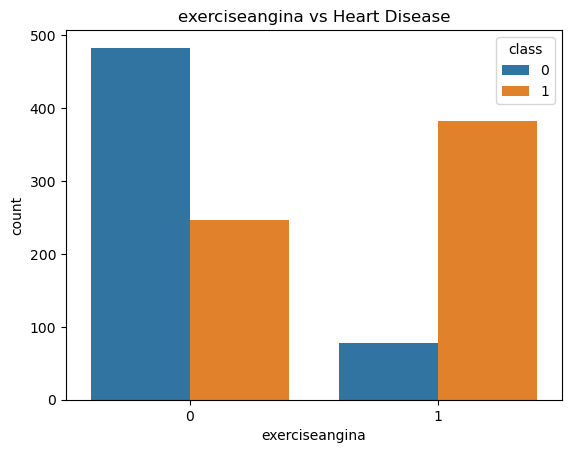

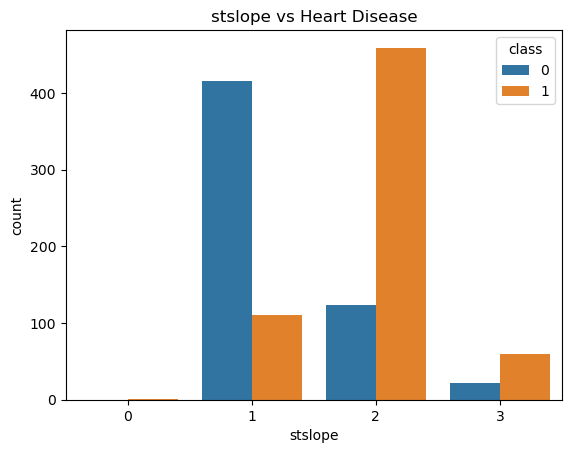

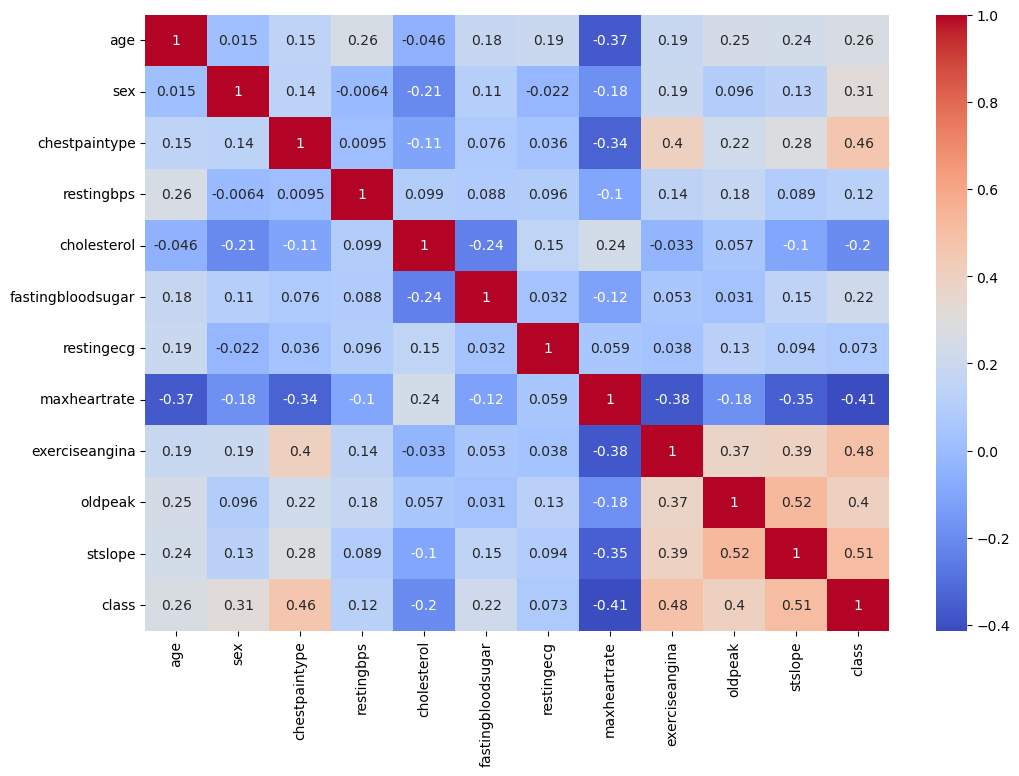

In [13]:
# Visualize target distribution
sns.countplot(x='class', data=df)
plt.title('Distribution of Heart Disease')
plt.show()

# Visualize numeric features
numeric_features = ['age', 'restingbps', 'cholesterol', 'maxheartrate', 'oldpeak']
df[numeric_features].hist(bins=15, figsize=(15,10))
plt.show()

# Visualize categorical features
categorical_features = ['sex', 'chestpaintype', 'fastingbloodsugar', 'restingecg', 'exerciseangina', 'stslope']
for col in categorical_features:
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f'{col} vs Heart Disease')
    plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [19]:
# Separate features and target
X = df.drop('class', axis=1)
y = df['class']

# Identify numeric and categorical columns
numeric_features = ['age', 'restingbps', 'cholesterol', 'maxheartrate', 'oldpeak']
categorical_features = ['sex', 'chestpaintype', 'fastingbloodsugar', 'restingecg', 'exerciseangina', 'stslope']

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Logistic Regression
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(solver='liblinear'))])
lr_pipeline.fit(X_train, y_train)

# Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
rf_pipeline.fit(X_train, y_train)

# XGBoost
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'restingbps',
                                                   'cholesterol',
                                                   'maxheartrate', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['sex', 'che...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [17]:
pipelines = {'Logistic Regression': lr_pipeline, 'Random Forest': rf_pipeline, 'XGBoost': xgb_pipeline}

for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

--- Logistic Regression ---
Accuracy: 0.8613445378151261
Precision: 0.8549618320610687
Recall: 0.8888888888888888
F1 Score: 0.8715953307392996
ROC AUC: 0.8596230158730157
[[ 93  19]
 [ 14 112]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       112
           1       0.85      0.89      0.87       126

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238

--- Random Forest ---
Accuracy: 0.9411764705882353
Precision: 0.9516129032258065
Recall: 0.9365079365079365
F1 Score: 0.944
ROC AUC: 0.9414682539682538
[[106   6]
 [  8 118]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       112
           1       0.95      0.94      0.94       126

    accuracy                           0.94       238
   macro avg       0.94      0.94      0.94       238
weighted avg       0.94      0.9

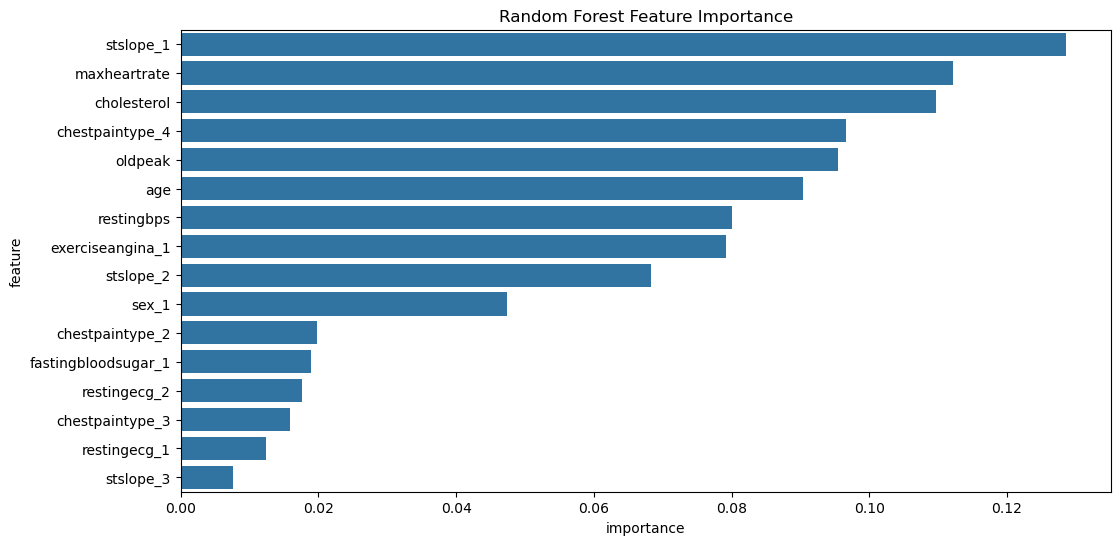

In [18]:
# Random Forest Feature Importance
feature_names = numeric_features + list(rf_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
importances = rf_pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.show()

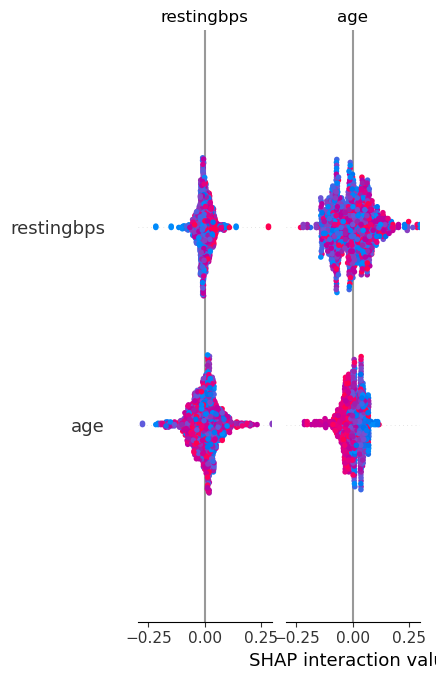

In [11]:
explainer = shap.TreeExplainer(rf_pipeline.named_steps['classifier'])
X_train_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_train)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

In [12]:
joblib.dump(rf_pipeline, 'heart_disease_model.pkl')
print("Model saved successfully!")

Model saved successfully!
